In [28]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [29]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

Gain of function with Y143C-S230R 0.64
Rescue with Y143C-S230R 0.02074688796680498
Noncompensatory with Y143C-S230R 0.0


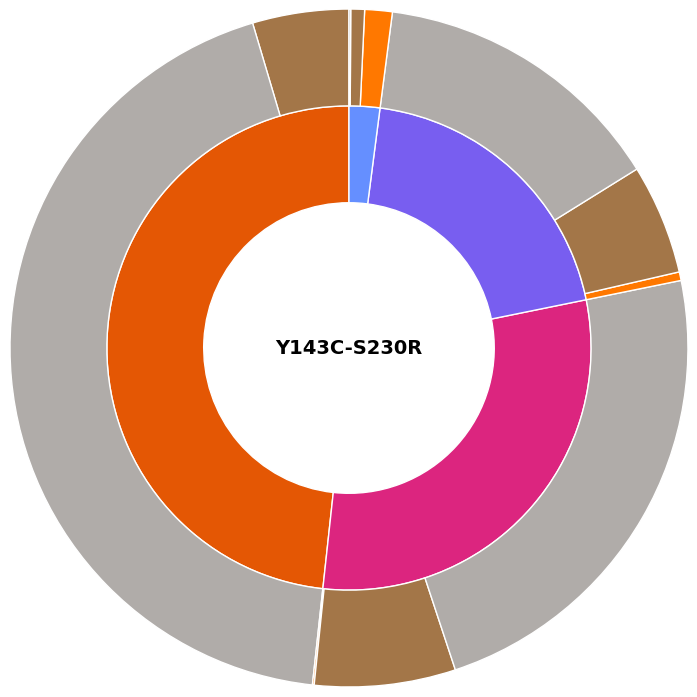

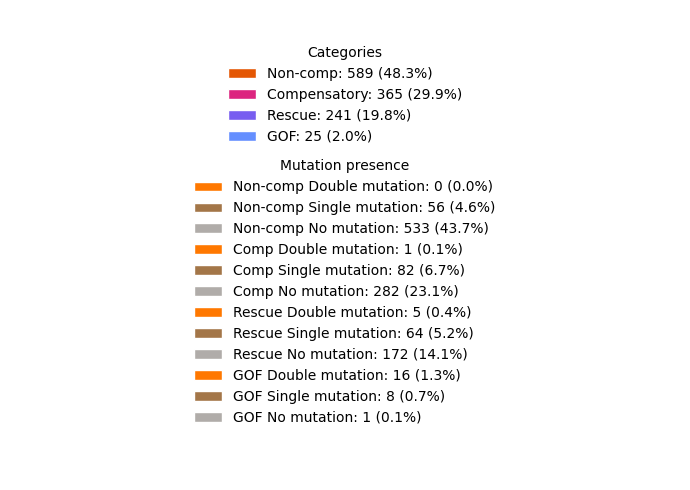

In [30]:
# IN_pair = 'G140S-Q148H'
IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'

# IN_pair = 'Y143R-N155H'
pair1, pair2 = functions.split_pairs(IN_pair)

p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

wt1,pos1,mt1 = functions.split_pair(p1_reduced)
wt2,pos2,mt2 = functions.split_pair(p2_reduced)

IN_bars = []
IN_gof_bars = []
IN_rescue_bars = []
IN_flipped_bars = []
IN_compensatory_bars = []
IN_other_bars = []
########
gof_counts = 0

gof_without_DMC_count = 0
gof_with_DMC_count = 0
gof_with_one_mut_count = 0

gof_flip = 0
gof_nonflip = 0
########
rescue_count = 0

rescue_without_DMC_count = 0
rescue_with_DMC_count = 0
rescue_with_one_mut_count = 0

rescue_flip = 0
rescue_nonflip = 0

########
compensatory_counts = 0

compensatory_without_DMC_count = 0
compensatory_with_DMC_count = 0
compensatory_with_one_mut_count = 0

compensatory_flip = 0
compensatory_nonflip = 0

########
noncompensatory_counts = 0

noncompensatory_without_DMC_count = 0
noncompensatory_with_DMC_count = 0
noncompensatory_with_one_mut_count = 0

noncompensatory_flip = 0
noncompensatory_nonflip = 0



consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_consensus_seq, IN_J, 1, 263)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for IN_seq in IN_all_seq:
    # Debugging: Print inputs to the function

    # result_wom = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)
    # result_wm = functions.calculate_with_double_mutation_dde(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)

    result_merged = functions.calculate_dde_v2(p1_reduced, p2_reduced, IN_seq, IN_J, 1, 263)

    # Check if the result is None

    # if result_wom is None:
    #     continue 
    # pair1_de, pair2_de, pair12_de, pair12_dde = result_wom

    # if result_wm is None:
    #     continue 
    # pair1_de, pair2_de, pair12_de, pair12_dde = result_wm

    if result_merged is None:
        continue 
    pair1_de, pair2_de, pair12_de, pair12_dde = result_merged

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de >0:
        IN_gof_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else: 
            gof_nonflip += 1

# noncompensatory_without_DMC_count = 0
# noncompensatory_with_DMC_count = 0
# noncompensatory_with_one_mut_count = 0
        # print(wt1, pos1, mt1, wt2, pos2, mt2)
        if IN_seq[pos1 - 1] == wt1 and IN_seq[pos2 - 1] == wt2:
            gof_without_DMC_count += 1
            # print(f"GoF without DMC: {IN_seq} at positions {pos1} and {pos2}")
        elif IN_seq[pos1 - 1] == mt1 and IN_seq[pos2 - 1] == mt2:
            gof_with_DMC_count += 1
        else:
            gof_with_one_mut_count += 1
        



    elif pair1_de < pair12_de and pair2_de < pair12_de:
        IN_rescue_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else: 
            rescue_nonflip += 1

        if IN_seq[pos1 - 1] == wt1 and IN_seq[pos2 - 1] == wt2:
            rescue_without_DMC_count += 1
            # print(f"GoF without DMC: {IN_seq} at positions {pos1} and {pos2}")
        elif IN_seq[pos1 - 1] == mt1 and IN_seq[pos2 - 1] == mt2:
            rescue_with_DMC_count += 1
        else:
            rescue_with_one_mut_count += 1
        

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        IN_compensatory_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else: 
            compensatory_nonflip += 1

        if IN_seq[pos1 - 1] == wt1 and IN_seq[pos2 - 1] == wt2:
            compensatory_without_DMC_count += 1
            # print(f"GoF without DMC: {IN_seq} at positions {pos1} and {pos2}")
        elif IN_seq[pos1 - 1] == mt1 and IN_seq[pos2 - 1] == mt2:
            compensatory_with_DMC_count += 1
        else:
            compensatory_with_one_mut_count += 1
    else:
        IN_other_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de)*consensus_flip_relation < 0:
            IN_flipped_bars.append((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else: 
            noncompensatory_nonflip += 1

        if IN_seq[pos1 - 1] == wt1 and IN_seq[pos2 - 1] == wt2:
            noncompensatory_without_DMC_count += 1
            # print(f"GoF without DMC: {IN_seq} at positions {pos1} and {pos2}")
        elif IN_seq[pos1 - 1] == mt1 and IN_seq[pos2 - 1] == mt2:
            noncompensatory_with_DMC_count += 1
        else:
            noncompensatory_with_one_mut_count += 1

print('Gain of function with', IN_pair, gof_with_DMC_count / gof_counts)
print('Rescue with', IN_pair, rescue_with_DMC_count / rescue_count)
# print('compensatory with', IN_pair, compensatory_with_DMC_count / compensatory_counts)  
print('Noncompensatory with', IN_pair, noncompensatory_with_DMC_count / noncompensatory_counts)
# plot.epistatic_pie2(IN_pair, compensatory_flip, compensatory_nonflip, noncompensatory_flip, noncompensatory_nonflip, rescue_flip, rescue_nonflip, gof_flip, gof_nonflip)
plot.epistatic_pie_mutatioin_percentage(
    IN_pair,
    noncompensatory_with_DMC_count, noncompensatory_with_one_mut_count, noncompensatory_without_DMC_count,
    compensatory_with_DMC_count, compensatory_with_one_mut_count, compensatory_without_DMC_count,
    rescue_with_DMC_count, rescue_with_one_mut_count, rescue_without_DMC_count,
    gof_with_DMC_count, gof_with_one_mut_count, gof_without_DMC_count
)

Gain of function with D30N-K45Q 1.0
Rescue with D30N-K45Q 0.3333333333333333
Noncompensatory with D30N-K45Q 0.0


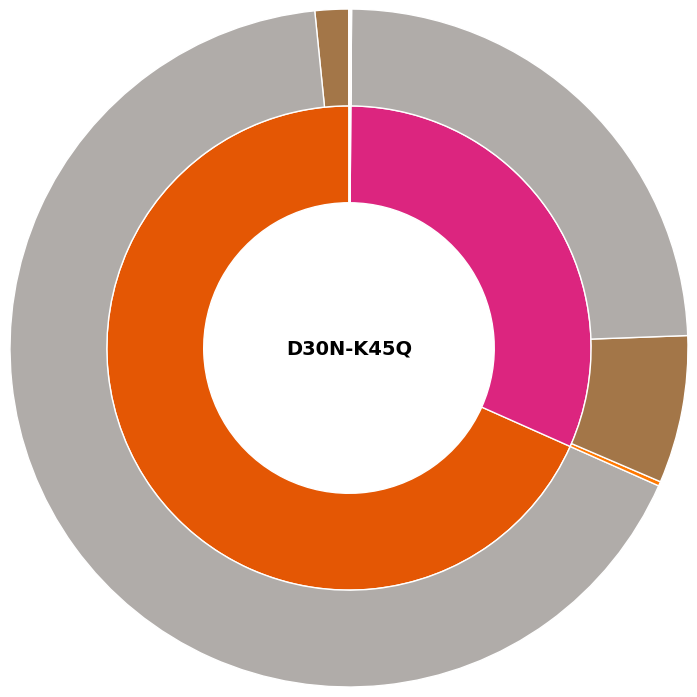

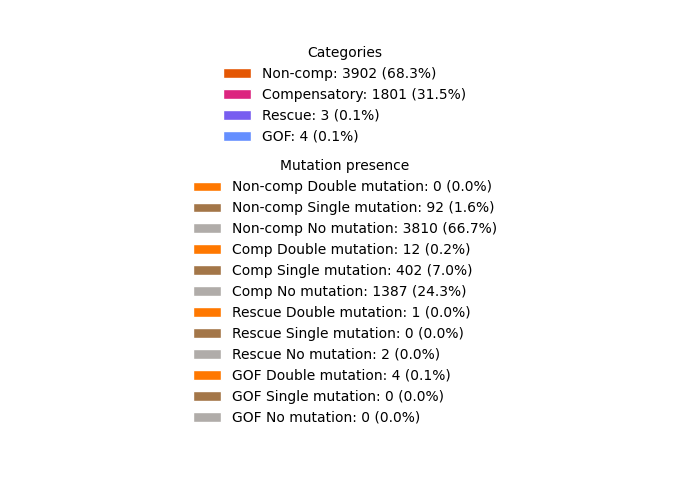

In [31]:
# PR_pair = 'D30N-N88D'
# PR_pair = 'V32I-I47V'
# PR_pair = 'G48V-I54A'
PR_pair = 'D30N-K45Q'
# PR_pair = 'I54A-V82A'

pair1, pair2 = functions.split_pairs(PR_pair)

p1_reduced = functions.unreduced_to_reduced(PR_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(PR_redux, pair2)

wt1, pos1, mt1 = functions.split_pair(p1_reduced)
wt2, pos2, mt2 = functions.split_pair(p2_reduced)

PR_bars = []
PR_gof_bars = []
PR_rescue_bars = []
PR_flipped_bars = []
PR_compensatory_bars = []
PR_other_bars = []
########
gof_counts = 0

gof_without_DMC_count = 0
gof_with_DMC_count = 0
gof_with_one_mut_count = 0

gof_flip = 0
gof_nonflip = 0
########
rescue_count = 0

rescue_without_DMC_count = 0
rescue_with_DMC_count = 0
rescue_with_one_mut_count = 0

rescue_flip = 0
rescue_nonflip = 0

########
compensatory_counts = 0

compensatory_without_DMC_count = 0
compensatory_with_DMC_count = 0
compensatory_with_one_mut_count = 0

compensatory_flip = 0
compensatory_nonflip = 0

########
noncompensatory_counts = 0

noncompensatory_without_DMC_count = 0
noncompensatory_with_DMC_count = 0
noncompensatory_with_one_mut_count = 0

noncompensatory_flip = 0
noncompensatory_nonflip = 0

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_consensus_seq, PR_J, 1, 99)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for PR_seq in PR_all_seq:
    result_merged = functions.calculate_dde_v2(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)

    if result_merged is None:
        continue
    pair1_de, pair2_de, pair12_de, pair12_dde = result_merged

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de > 0:
        PR_gof_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else:
            gof_nonflip += 1

        if PR_seq[pos1 - 1] == wt1 and PR_seq[pos2 - 1] == wt2:
            gof_without_DMC_count += 1
        elif PR_seq[pos1 - 1] == mt1 and PR_seq[pos2 - 1] == mt2:
            gof_with_DMC_count += 1
        else:
            gof_with_one_mut_count += 1

    elif pair1_de < pair12_de and pair2_de < pair12_de:
        PR_rescue_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else:
            rescue_nonflip += 1

        if PR_seq[pos1 - 1] == wt1 and PR_seq[pos2 - 1] == wt2:
            rescue_without_DMC_count += 1
        elif PR_seq[pos1 - 1] == mt1 and PR_seq[pos2 - 1] == mt2:
            rescue_with_DMC_count += 1
        else:
            rescue_with_one_mut_count += 1

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        PR_compensatory_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else:
            compensatory_nonflip += 1

        if PR_seq[pos1 - 1] == wt1 and PR_seq[pos2 - 1] == wt2:
            compensatory_without_DMC_count += 1
        elif PR_seq[pos1 - 1] == mt1 and PR_seq[pos2 - 1] == mt2:
            compensatory_with_DMC_count += 1
        else:
            compensatory_with_one_mut_count += 1
    else:
        PR_other_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            PR_flipped_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else:
            noncompensatory_nonflip += 1

        if PR_seq[pos1 - 1] == wt1 and PR_seq[pos2 - 1] == wt2:
            noncompensatory_without_DMC_count += 1
        elif PR_seq[pos1 - 1] == mt1 and PR_seq[pos2 - 1] == mt2:
            noncompensatory_with_DMC_count += 1
        else:
            noncompensatory_with_one_mut_count += 1

print('Gain of function with', PR_pair, gof_with_DMC_count / gof_counts)
print('Rescue with', PR_pair, rescue_with_DMC_count / rescue_count)
print('Noncompensatory with', PR_pair, noncompensatory_with_DMC_count / noncompensatory_counts)

plot.epistatic_pie_mutatioin_percentage(
    PR_pair,
    noncompensatory_with_DMC_count, noncompensatory_with_one_mut_count, noncompensatory_without_DMC_count,
    compensatory_with_DMC_count, compensatory_with_one_mut_count, compensatory_without_DMC_count,
    rescue_with_DMC_count, rescue_with_one_mut_count, rescue_without_DMC_count,
    gof_with_DMC_count, gof_with_one_mut_count, gof_without_DMC_count
)

Gain of function with F116Y-Q151M 0.8350515463917526
Rescue with F116Y-Q151M 0.17232375979112272
Noncompensatory with F116Y-Q151M 0.0012995853703818305


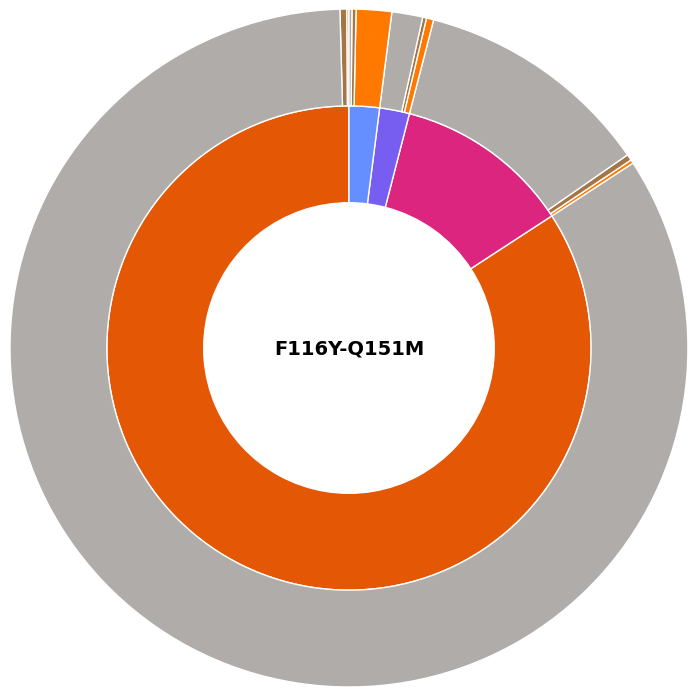

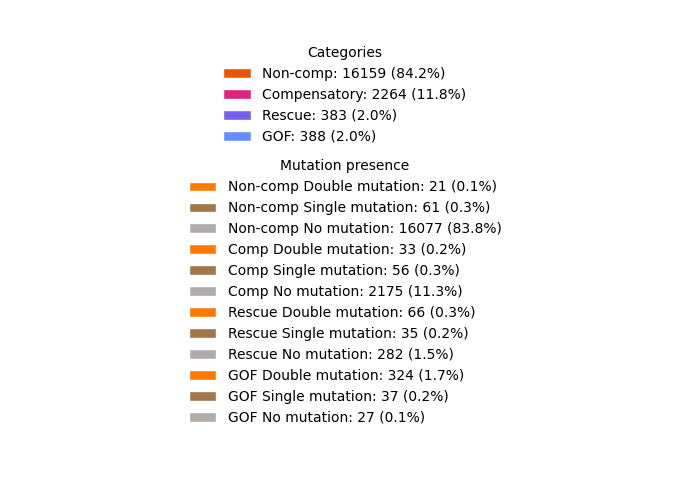

In [32]:
min_pos= 39
max_pos = 226

RT_pair = 'F116Y-Q151M'
# RT_pair = 'M41L-T215Y'

pair1, pair2 = functions.split_pairs(RT_pair)

p1_reduced = functions.unreduced_to_reduced(RT_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(RT_redux, pair2)

wt1, pos1, mt1 = functions.split_pair(p1_reduced)
wt2, pos2, mt2 = functions.split_pair(p2_reduced)

RT_bars = []
RT_gof_bars = []
RT_rescue_bars = []
RT_flipped_bars = []
RT_compensatory_bars = []
RT_other_bars = []
########
gof_counts = 0

gof_without_DMC_count = 0
gof_with_DMC_count = 0
gof_with_one_mut_count = 0

gof_flip = 0
gof_nonflip = 0
########
rescue_count = 0

rescue_without_DMC_count = 0
rescue_with_DMC_count = 0
rescue_with_one_mut_count = 0

rescue_flip = 0
rescue_nonflip = 0

########
compensatory_counts = 0

compensatory_without_DMC_count = 0
compensatory_with_DMC_count = 0
compensatory_with_one_mut_count = 0

compensatory_flip = 0
compensatory_nonflip = 0

########
noncompensatory_counts = 0

noncompensatory_without_DMC_count = 0
noncompensatory_with_DMC_count = 0
noncompensatory_with_one_mut_count = 0

noncompensatory_flip = 0
noncompensatory_nonflip = 0

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, RT_consensus_seq, RT_J, min_pos, max_pos)
consensus_flip_relation = consensus_result[0] - consensus_result[1]

for RT_seq in RT_all_seq:
    result_merged = functions.calculate_dde_v2(p1_reduced, p2_reduced, RT_seq, RT_J, min_pos, max_pos)

    if result_merged is None:
        continue
    pair1_de, pair2_de, pair12_de, pair12_dde = result_merged

    if pair1_de < pair12_de and pair2_de < pair12_de and pair12_de > 0:
        RT_gof_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        gof_counts += 1

        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            gof_flip += 1
        else:
            gof_nonflip += 1

        if RT_seq[pos1 - min_pos] == wt1 and RT_seq[pos2 - min_pos] == wt2:
            gof_without_DMC_count += 1
        elif RT_seq[pos1 - min_pos] == mt1 and RT_seq[pos2 - min_pos] == mt2:
            gof_with_DMC_count += 1
        else:
            gof_with_one_mut_count += 1

    elif pair1_de < pair12_de and pair2_de < pair12_de:
        RT_rescue_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        rescue_count += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            rescue_flip += 1
        else:
            rescue_nonflip += 1

        if RT_seq[pos1 - min_pos] == wt1 and RT_seq[pos2 - min_pos] == wt2:
            rescue_without_DMC_count += 1
        elif RT_seq[pos1 - min_pos] == mt1 and RT_seq[pos2 - min_pos] == mt2:
            rescue_with_DMC_count += 1
        else:
            rescue_with_one_mut_count += 1

    elif pair1_de < pair12_de or pair2_de < pair12_de:
        RT_compensatory_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        compensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            compensatory_flip += 1
        else:
            compensatory_nonflip += 1

        if RT_seq[pos1 - min_pos] == wt1 and RT_seq[pos2 - min_pos] == wt2:
            compensatory_without_DMC_count += 1
        elif RT_seq[pos1 - min_pos] == mt1 and RT_seq[pos2 - min_pos] == mt2:
            compensatory_with_DMC_count += 1
        else:
            compensatory_with_one_mut_count += 1
    else:
        RT_other_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
        noncompensatory_counts += 1
        if (pair1_de - pair2_de) * consensus_flip_relation < 0:
            RT_flipped_bars.append((RT_all_seq.index(RT_seq), pair1_de, pair2_de, pair12_de))
            noncompensatory_flip += 1
        else:
            noncompensatory_nonflip += 1

        if RT_seq[pos1 - min_pos] == wt1 and RT_seq[pos2 - min_pos] == wt2:
            noncompensatory_without_DMC_count += 1
        elif RT_seq[pos1 - min_pos] == mt1 and RT_seq[pos2 - min_pos] == mt2:
            noncompensatory_with_DMC_count += 1
        else:
            noncompensatory_with_one_mut_count += 1

print('Gain of function with', RT_pair, gof_with_DMC_count / gof_counts)
print('Rescue with', RT_pair, rescue_with_DMC_count / rescue_count)
print('Noncompensatory with', RT_pair, noncompensatory_with_DMC_count / noncompensatory_counts)

plot.epistatic_pie_mutatioin_percentage(
    RT_pair,
    noncompensatory_with_DMC_count, noncompensatory_with_one_mut_count, noncompensatory_without_DMC_count,
    compensatory_with_DMC_count, compensatory_with_one_mut_count, compensatory_without_DMC_count,
    rescue_with_DMC_count, rescue_with_one_mut_count, rescue_without_DMC_count,
    gof_with_DMC_count, gof_with_one_mut_count, gof_without_DMC_count
)